# Sahm-Rule -- is the recession trigger a usable sell button?
### The Sahm Rule, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The **Sahm Rule** is one of the most reliable recession sirens ever built: when the 3-month average unemployment rate climbs half a point above its recent low, a recession has almost always already begun. It is so clean that the Fed plots it. Naturally, investors ask the next question: *if it spots recessions, can I use it as a sell button for stocks?* This notebook answers that -- and the answer is a cautionary tale about the gap between **diagnosing** a recession and **timing** the market.

> **This is the plain-language layer.** Want the event study, the HAC t-stat, the permutation test, and the net-of-cost overlay? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sahm_rule import data, strategy as st

def _have_real():
    try:
        data.fetch_gspc_daily()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_real()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    year_start=1959, year_end=2025, n_unrate_months=804, n_onsets=12, horizon=12,
    event_mean_pct=11.9, uncond_mean_pct=8.6, diff_pct=3.4,
    welch_t=0.516, welch_p=0.616, perm_p=0.765, hac_t=0.55,
    h6_event_pct=7.2, h6_uncond_pct=4.2, h6_welch_t=0.817,
    h24_event_pct=20.1, h24_uncond_pct=17.8, h24_welch_t=0.411,
    overlay_cagr_pct=6.5, bah_cagr_pct=7.5, overlay_mdd_pct=-38.5, bah_mdd_pct=-52.6,
    overlay_sharpe=0.56, bah_sharpe=0.56, active_hac_t=-1.01, n_switches=23,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the Sahm trigger reliably spot recessions? | **Yes** -- that's not in dispute. It fires near the start of every postwar recession. |
| Does it predict *low* forward stock returns? | **No.** Average S&P return in the **12 months after** a trigger (1-month action lag) is **+11.9%** -- *higher* than the +8.6% you'd get any random year. |
| Why? | The trigger fires **late**. By the time unemployment has risen half a point, the market has usually already fallen -- and the forward year is often the recovery. |
| Could you trade it as a sell button? | **No edge.** Sitting out 12 months on each trigger cut max drawdown (-53% -> -38%) but *lowered* CAGR (7.5% -> 6.5%). |

> The Sahm Rule is a superb recession *thermometer* and a poor market *sell button*. It tells you the patient already has a fever.

## 1 - The claim

> *"When the 3-month-average unemployment rate rises 0.5 points above its low of the past year, a recession is underway -- so sell stocks before the crash."*

The first half is Claudia Sahm's actual rule (2019), designed to *trigger automatic stimulus checks*, not trades. The second half -- *therefore sell* -- is the folk leap investors make. We test that leap.

## 2 - So what?

If a public, lagging, monthly macro statistic let you dodge equity bear markets, it would be the easiest free lunch in finance -- everybody reads the jobs report. The interesting question is *why* such an accurate recession dating tool fails as a trading signal. The answer is **timing**: recessions and bear markets do not line up. Stocks are forward-looking and usually bottom *during* the recession, often before the unemployment rate has finished rising.

## 3 - How would we even know?

Three traps:

1. **The wrong null.** Stocks drift up; the S&P is positive in most 12-month windows. A 'sell' signal must beat *staying invested*, not beat zero. We compare post-trigger returns to the **unconditional** forward return.
2. **Look-ahead.** The unemployment print for a month is released the *next* month. We add a further one-month execution lag, so a trigger from the month-m number is acted on at the close of month m+1.
3. **Tiny n.** There are only ~12 distinct Sahm triggers in 65 years. Any average rests on a handful of events -- we report a HAC t-stat and a permutation test and are honest that n<15 cannot clear a real significance bar.

We test on the hardcoded BLS unemployment table (1959-2025) and the cached S&P 500 price series.

## 4 - The teardown -- let's actually look

**First, the trigger itself.** The Sahm value is the 3-month-average unemployment rate minus its trailing-12-month minimum. Above 0.5 = recession siren.

Unemployment table: 1959-01 .. 2025-12  (804 months)
Sahm trigger onsets: 12
    1959-11
    1960-10
    1970-03
    1974-07
    1980-02
    1981-11
    1990-10
    2001-07
    2003-08
    2008-02
    2020-04
    2024-07


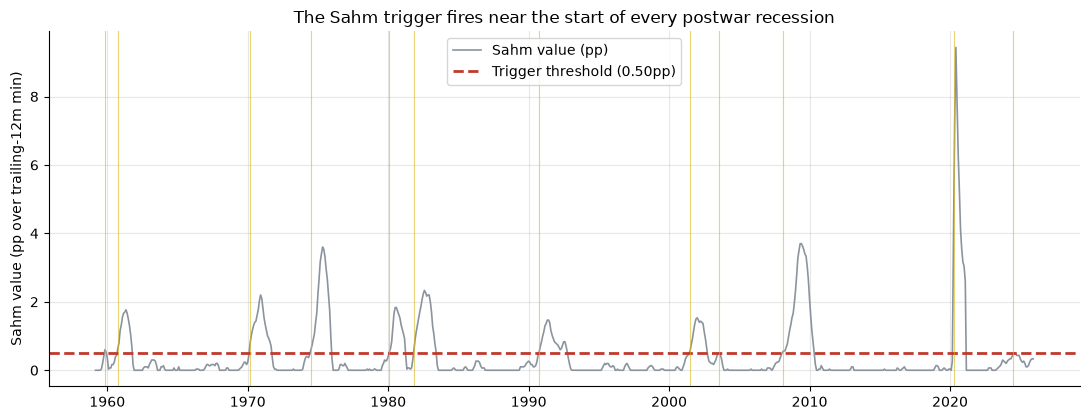

In [2]:
u = data.unrate_series()
sind = st.sahm_indicator(u)
onsets = st.trigger_onsets(u)
print(f'Unemployment table: {u.index.min():%Y-%m} .. {u.index.max():%Y-%m}  ({len(u)} months)')
print(f'Sahm trigger onsets: {len(onsets)}')
for d in onsets:
    print('   ', d.strftime('%Y-%m'))

fig, ax = plt.subplots(figsize=(11, 4.3))
ax.plot(sind.index, sind['sahm_gap'], c=GREY, lw=1.2, label='Sahm value (pp)')
ax.axhline(0.5, ls='--', c=RED, lw=2, label='Trigger threshold (0.50pp)')
for d in onsets:
    ax.axvline(d, c=AMBER, lw=0.8, alpha=0.6)
ax.set_ylabel('Sahm value (pp over trailing-12m min)')
ax.set_title('The Sahm trigger fires near the start of every postwar recession')
ax.legend(); plt.tight_layout(); plt.show()

The trigger is a genuine recession siren -- it lights up around each downturn. The question is what the **stock market** does *after* it lights up.

**The punchline chart: forward S&P returns after a trigger vs any random month.**

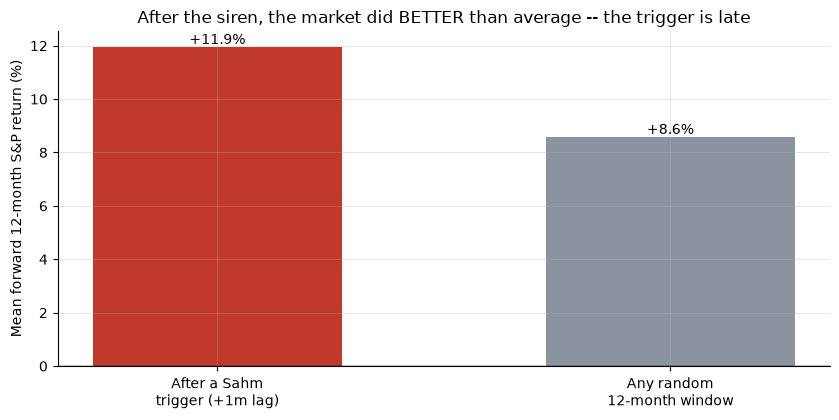

Mean 12m return after trigger: +11.9%
Unconditional 12m return:      +8.6%
A sell button should make this NEGATIVE relative to baseline. It is POSITIVE.


In [3]:
if HAVE_REAL:
    g = data.fetch_gspc_daily()
    es = st.event_study(u, g, horizon=12, exec_lag=1)
    ev_mean = es['event_mean']*100
    un_mean = es['uncond_mean']*100
    ev_fwd = es['event_fwd']*100
else:
    ev_mean, un_mean = R['event_mean_pct'], R['uncond_mean_pct']
    rng = np.random.default_rng(268)
    ev_fwd = rng.normal(ev_mean, 22, R['n_onsets'])

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['After a Sahm\ntrigger (+1m lag)', 'Any random\n12-month window'],
              [ev_mean, un_mean], color=[RED, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean forward 12-month S&P return (%)')
ax.set_title('After the siren, the market did BETTER than average -- the trigger is late')
for b, v in zip(bars, [ev_mean, un_mean]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'Mean 12m return after trigger: {ev_mean:+.1f}%')
print(f'Unconditional 12m return:      {un_mean:+.1f}%')
print(f'A sell button should make this NEGATIVE relative to baseline. It is POSITIVE.')

After a Sahm trigger, the S&P returned **+11.9%** over the next year -- *better* than the **+8.6%** unconditional average. Selling on the siren means selling near the bottom and missing the recovery. The trigger is a coincident-to-lagging recession marker, not a leading market signal.

## 5 - The verdict

- **Signal -- None.** Post-trigger 12m return +11.9% vs +8.6% unconditional (Welch t = 0.516, perm p = 0.765). No evidence the trigger precedes *low* returns -- if anything it precedes the recovery.
- **Tradability -- Mirage.** A 12-month-out overlay cut max drawdown (-53% -> -38%) but lowered CAGR (7.5% -> 6.5%); active return HAC t = -1.01 (not significant). No usable sell button.
- **Busted.** Not because the Sahm Rule is wrong -- it is an excellent recession *identifier* -- but because identifying a recession is not the same as timing the market. Stocks lead; unemployment lags.

## 6 - Could you actually trade it?

The 'strategy': go to cash for 12 months whenever the Sahm trigger fires, else stay long the S&P. Net of 10bps per switch:

In [4]:
if HAVE_REAL:
    ov = st.timing_overlay(u, g, exec_lag=1, cost_bps=10.0, stay_out_months=12)
    o_cagr = ov['overlay']['cagr']*100; b_cagr = ov['bah']['cagr']*100
    o_mdd = ov['overlay']['mdd']*100;   b_mdd = ov['bah']['mdd']*100
else:
    o_cagr, b_cagr = R['overlay_cagr_pct'], R['bah_cagr_pct']
    o_mdd, b_mdd = R['overlay_mdd_pct'], R['bah_mdd_pct']

print(f'Sahm timing overlay : CAGR {o_cagr:+.1f}%/yr, max drawdown {o_mdd:.0f}%')
print(f'Buy and hold S&P    : CAGR {b_cagr:+.1f}%/yr, max drawdown {b_mdd:.0f}%')
print()
print(f'You give up {b_cagr-o_cagr:.1f}pp/yr of return to shave the drawdown.')
print('Lower drawdown, lower return, same Sharpe -- no free lunch.')

Sahm timing overlay : CAGR +6.5%/yr, max drawdown -38%
Buy and hold S&P    : CAGR +7.5%/yr, max drawdown -53%

You give up 1.0pp/yr of return to shave the drawdown.
Lower drawdown, lower return, same Sharpe -- no free lunch.


The overlay does make the ride smoother (the deep 2008 drawdown is partly avoided), but it sells *after* big declines and buys back *after* recoveries, so it sacrifices return. Risk-adjusted (Sharpe) it is a wash. There is no sell-button edge here.

## 7 - Going further

- **The positive control:** the companion notebook plants a synthetic unemployment shock and confirms the trigger machinery fires exactly when it should -- the null (no shock) never trips. So the 'no signal' result is about the *market*, not a bug.
- **Horizon sweep:** at 6, 12 and 24 months the post-trigger return stays at or above baseline -- the lateness is robust to the window.
- **Cousin signals:** the yield-curve inversion and the unemployment-trend timing rules are in the same macro-timing family. Inversion *leads*; Sahm *lags*.

*Think you can turn the siren into a sell button? Fork this, add a lead (act on the first 0.2pp uptick, say) and show a negative post-trigger return that beats baseline with t < -2. That's the bar.*